# 1) Transform Data to have **normalized values** & **sov-based countries**
- normalized values: floats in \[0, 1\]
- countries need to be named with their SOV code


In [1]:
from typing import Dict

import os
import pandas as pd

from pain2map import Util

In [2]:
BASE_PATH = os.path.join("..", "data")
DATASET_BASE_PATH = os.path.join(BASE_PATH, "2")
DATASET_PATH = os.path.join(DATASET_BASE_PATH, "GDP.csv")
NORM_DATASET_PATH = os.path.join(DATASET_BASE_PATH, "GDP_normalized.csv")
SOVA3_DATASET_PATH = os.path.join(DATASET_BASE_PATH, "GDP_sova3.csv")

WORLD_PATH = os.path.join(BASE_PATH, "countries_map.zip")

In [3]:
STORE_CSVS = True

In [4]:
dataset = pd.read_csv(DATASET_PATH)
dataset.head()

,Country,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.727933e+09,2.791061e+09,2.963128e+09,2.983799e+09,3.092179e+09,3.276188e+09,3.395794e+09,2.610039e+09,3.126019e+09,NaN
1,Africa Eastern and Southern,AFE,2.112502e+10,2.161623e+10,2.350628e+10,2.804836e+10,2.592067e+10,2.947210e+10,3.201437e+10,3.326951e+10,...,9.859871e+11,1.006526e+12,9.273485e+11,8.851764e+11,1.021043e+12,1.007196e+12,1.000834e+12,9.275933e+11,1.081998e+12,1.169484e+12
2,Afghanistan,AFG,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,1.400000e+09,1.673333e+09,...,2.056449e+10,2.055058e+10,1.999814e+10,1.801955e+10,1.889635e+10,1.841886e+10,1.890450e+10,2.014345e+10,1.458314e+10,NaN
3,Africa Western and Central,AFW,1.044764e+10,1.117321e+10,1.199053e+10,1.272769e+10,1.389811e+10,1.492979e+10,1.591084e+10,1.451058e+10,...,8.339481e+11,8.943225e+11,7.686447e+11,6.913634e+11,6.848988e+11,7.670257e+11,8.225384e+11,7.864600e+11,8.444597e+11,8.778633e+11
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.334016e+11,1.372444e+11,8.721930e+10,4.984049e+10,6.897277e+10,7.779294e+10,6.930911e+10,5.024137e+10,6.568544e+10,1.067136e+11


## 1.1) Normalize values

this step heavily depends on the dataset

In [5]:
# sum all numeric columns for each country and divide by the max sum to get a value between 0 and 1
value_columns = [col for col in dataset.columns.values.tolist() if col.isnumeric()]
result_data = []
max_sum = 0.0
for index, row in dataset.iterrows():
    country = row["Country"]
    cur_sum = 0.0
    for col in value_columns:
        value = row[col]
        if pd.isna(value):
            continue
        cur_sum += float(value)
    if max_sum < cur_sum:
        max_sum = cur_sum
    result_data.append({"Country": country, "value": cur_sum})
for item in result_data:
    item["value"] /= max_sum
norm_dataset = pd.DataFrame(result_data)
if STORE_CSVS:
    norm_dataset.to_csv(NORM_DATASET_PATH, index=False)

## 1.2) Transform to SOV-based Countries

In [6]:

if STORE_CSVS:
    norm_dataset = pd.read_csv(NORM_DATASET_PATH)
sov_dataset, sov_subset = Util.compute_sova3_subset(norm_dataset, WORLD_PATH, "Country", "value")
if STORE_CSVS:
    sov_dataset.to_csv(SOVA3_DATASET_PATH, index=False)
sov_dataset.head()

,sov_a3,Country,value
0,AFG,Afghanistan,0.000159
1,AGO,Angola,0.000838
2,ALB,Albania,0.000143
3,ARE,United Arab Emirates,0.003964
4,ARG,Argentina,0.006565


# 2) Generate Map from Dataset

Saved ..\data\2\GDP_map.png


True

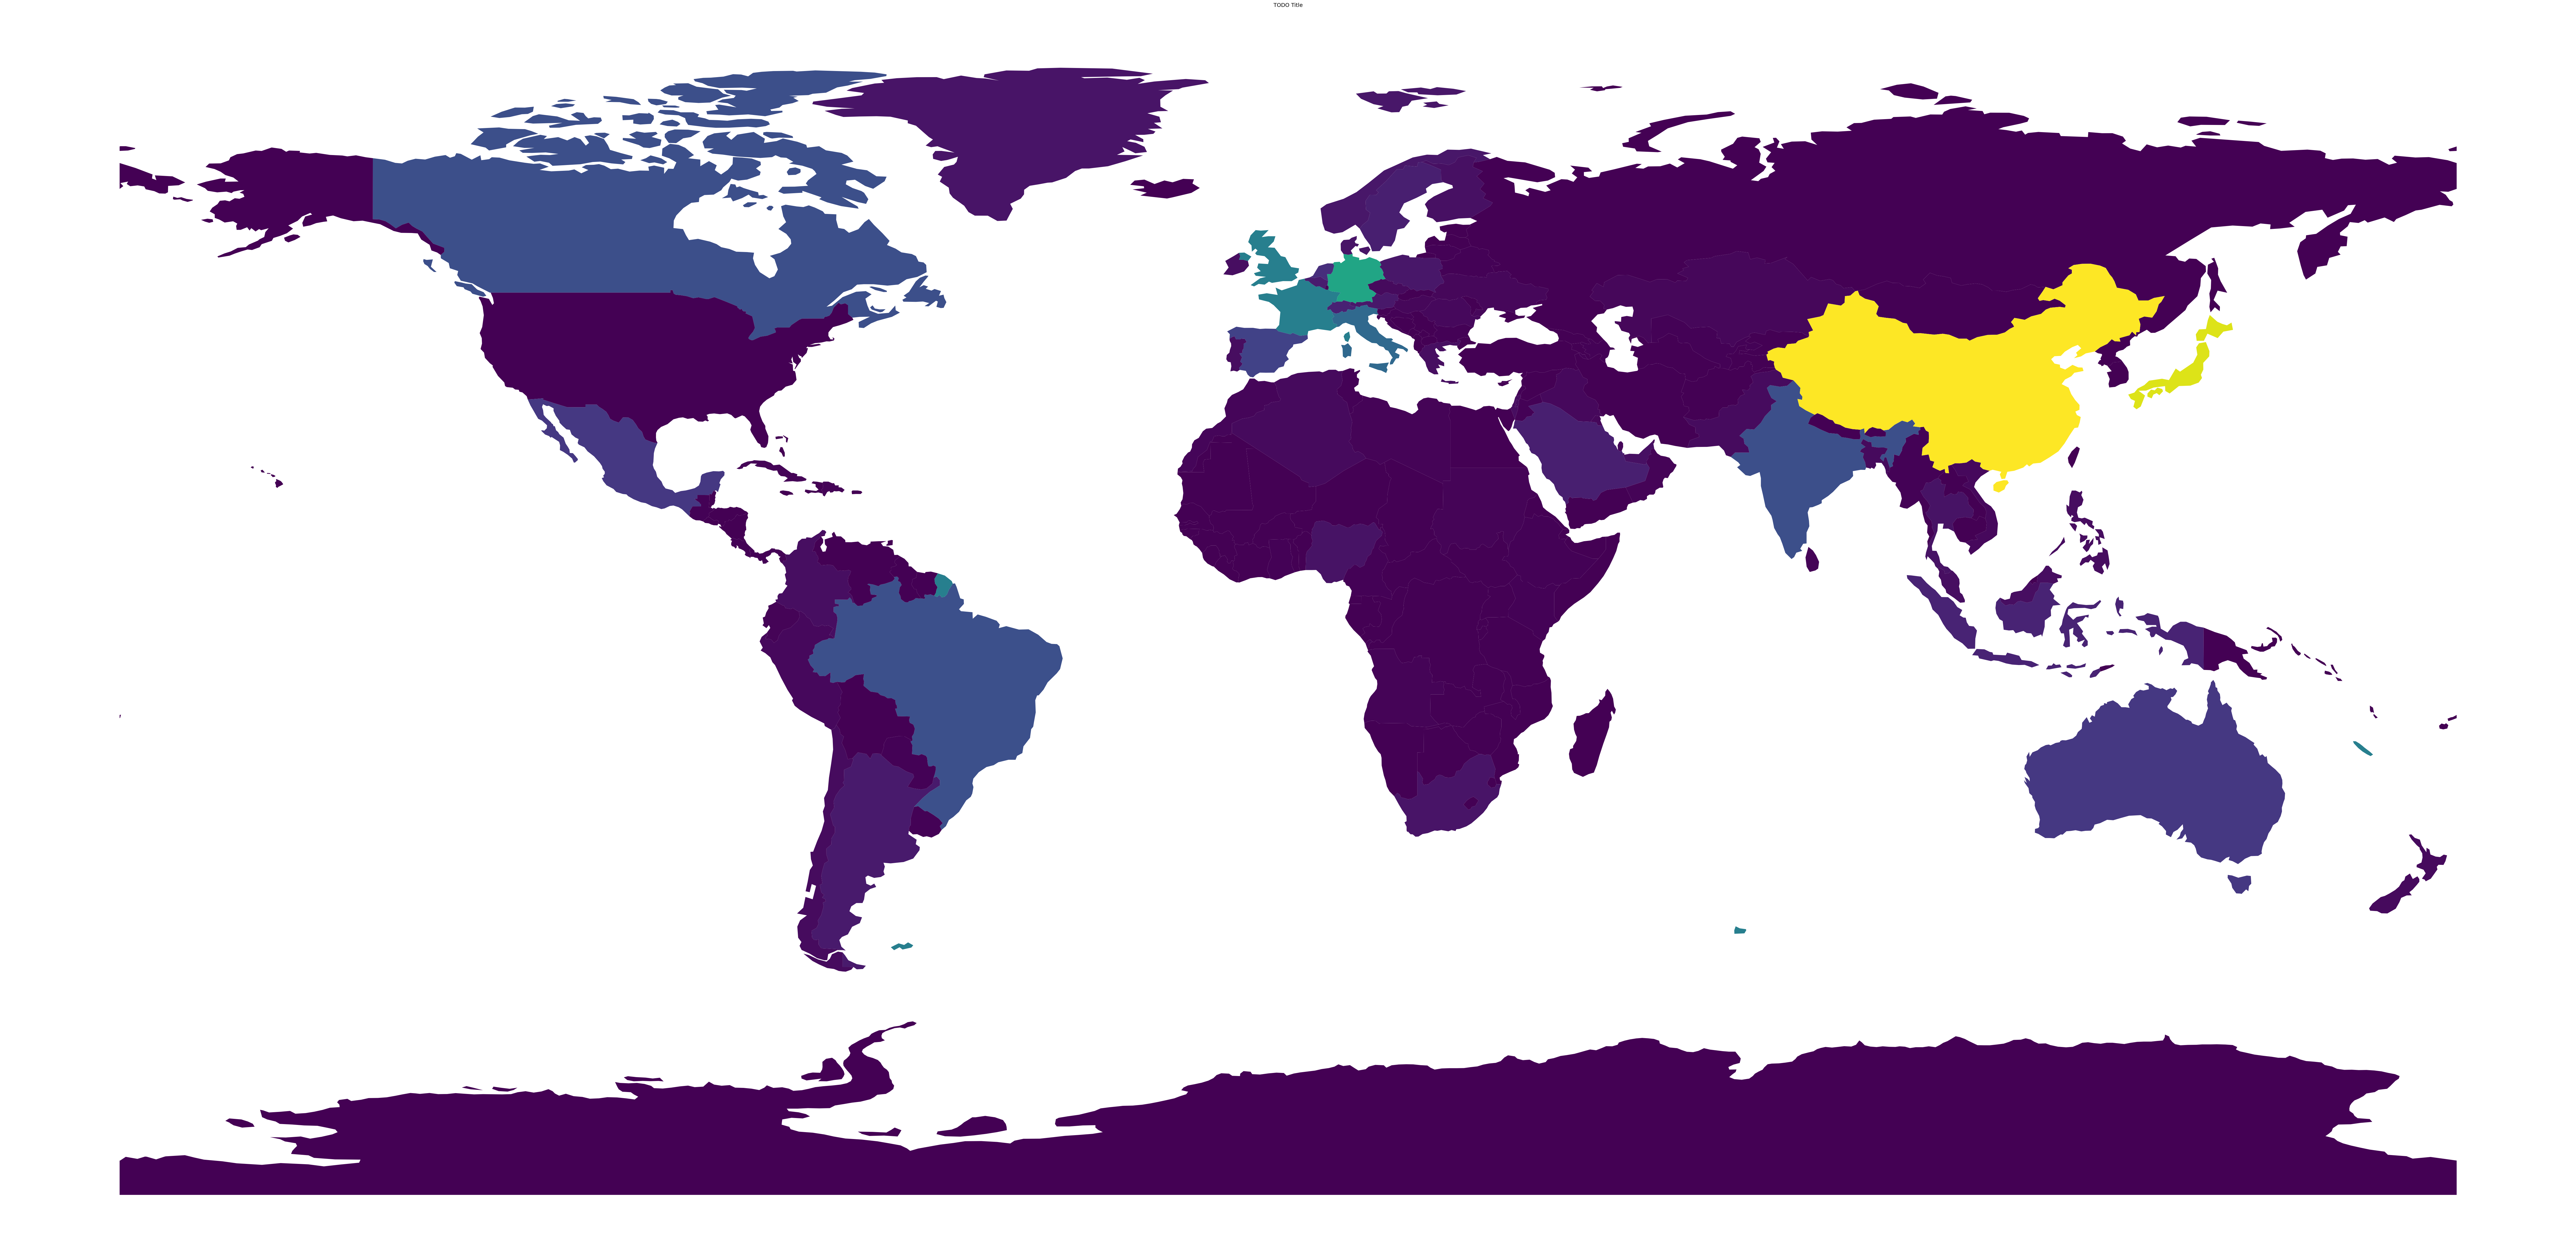

In [7]:
if STORE_CSVS:
    sov_dataset = pd.read_csv(SOVA3_DATASET_PATH)
Util.generate_map(
    data=sov_dataset,
    world_path=WORLD_PATH,
    output_path=os.path.join(BASE_PATH, "2", "GDP_map.png"),
    args_value_col="value",
    args_code_col="sov_a3",
    fig_width=120,
    fig_height=80,
    dpi=100,
    cmap="viridis",
    projection="PlateCarree"
)